In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon
import plotly.express as px
import plotly.graph_objects as go
import nbformat

from scipy.stats import ttest_ind, f_oneway
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib_venn import venn2
import os
import scipy.cluster.hierarchy as sch
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

In [2]:
target_CAFs=["FAP", "PDGFRA", "PDGFRB", "S100A4", "LRRC15", "IL1R1", "IL1R2","SMO"]
target_receptors_molecules=["TGFB1","TGFB2","TGFB3", "TGFBR1","TGFBR2","TGFBR3","IL6", "IL6R", "IL10RA","IL10RB", "CXCL8", "CXCL12", 
 "CCR5", "CXCR2", "CXCR1", "CXCR4", "CXCL10","CXCL9","HGF", "MET", "FGF1","FGF2","FGF7","FGF10", "FGFR1","FGFR2","FGFR3","FGFR4","IL11","HAS1","HAS2","HYAL1","HYAL2"]

In [3]:
fibr_gene_expression_modified=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/filtered_fibroblasts_gene_exp_transposed_w_clinical.csv")
clinical_data=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/9_eyemt_patient_clinical_data_new.csv")
fibr_gene_expression_modified["Patient"]=fibr_gene_expression_modified["Sample"].str.extract(r'(S\d+)')
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","PFS_quartile_b12"]],on="Patient", how="left")
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","OS_quartile_b12"]],on="Patient", how="left")

In [5]:
fibr_gene_expression_modified["PFS_HL_group"] = fibr_gene_expression_modified["PFS_quartile_b12"].apply(
    lambda x: "Low" if x in [1, "1", 2, "2"] else ("High" if x in [3, "3", 4, "4"] else None)
)
fibr_gene_expression_modified["OS_HL_group"] = fibr_gene_expression_modified["OS_quartile_b12"].apply(
    lambda x: "Low" if x in [1, "1", 2, "2"] else ("High" if x in [3, "3", 4, "4"] else None)
)

In [11]:
sample_metadata= fibr_gene_expression_modified[["Sample", "PFS_HL_group", "OS_HL_group"]].drop_duplicates().set_index("Sample")

In [12]:
stroma_gene_expression=fibr_gene_expression_modified[fibr_gene_expression_modified['Segment']=='stroma']
average_stroma_gene_expression=stroma_gene_expression.groupby('Sample')[target_CAFs+target_receptors_molecules].mean()
average_stroma_gene_expression = average_stroma_gene_expression.join(sample_metadata)
average_stroma_gene_expression.head(5)


,FAP,PDGFRA,PDGFRB,S100A4,LRRC15,IL1R1,IL1R2,SMO,TGFB1,TGFB2,...,FGFR2,FGFR3,FGFR4,IL11,HAS1,HAS2,HYAL1,HYAL2,PFS_HL_group,OS_HL_group
Sample,,,,,,,,,,,,,,,,,,,,,
S015_post,4.563758,4.715512,4.218255,2.948434,4.345709,3.478865,1.318255,1.416192,2.687415,2.575284,...,1.399364,0.604686,0.812162,2.367929,2.995947,2.717272,1.784699,2.292120,High,High
S015_pre,4.930071,4.369112,4.111848,2.661163,3.691044,4.197306,1.772768,1.657419,2.687384,3.048880,...,1.891527,1.095567,1.292330,2.875106,3.531457,3.050977,2.050613,2.584450,High,High
S027_post,4.678211,5.097098,5.064894,3.205728,3.753150,4.039051,1.505599,1.699002,2.283074,2.546047,...,0.863825,0.429573,1.807855,3.000496,3.663743,3.179359,2.070098,2.560837,High,High
S027_pre,4.370046,4.000786,3.428843,2.659461,4.408627,3.302794,1.229415,1.300093,2.388567,2.520256,...,1.618187,0.753126,-0.026285,2.080156,2.696289,2.285164,1.661174,2.656956,High,High
S032_post,4.534982,4.284750,3.835740,2.792009,4.585143,3.911578,1.311714,1.391109,2.352568,2.126993,...,1.513402,0.751687,0.304241,2.280565,2.998480,2.502677,1.844294,2.313490,High,High


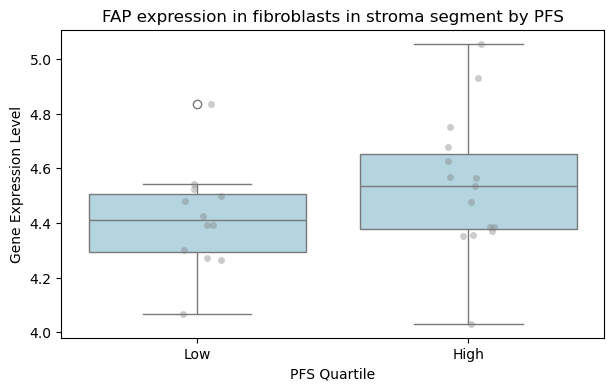

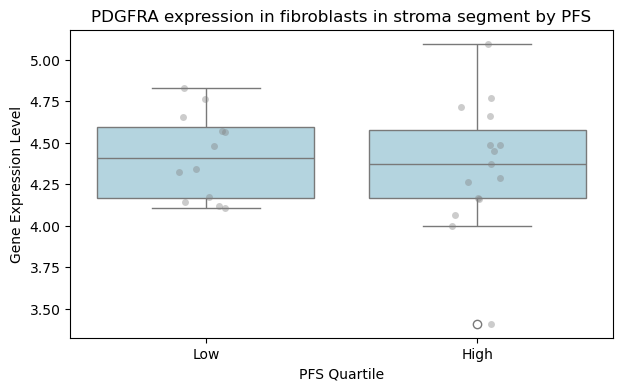

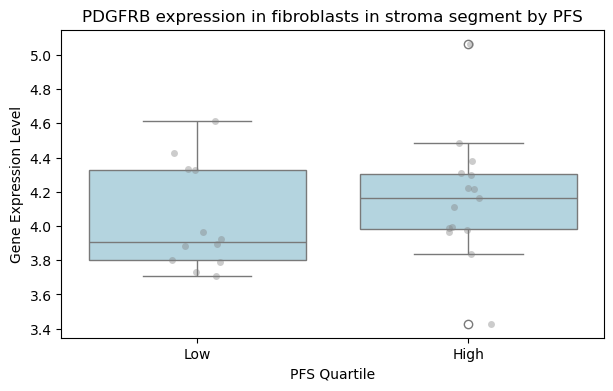

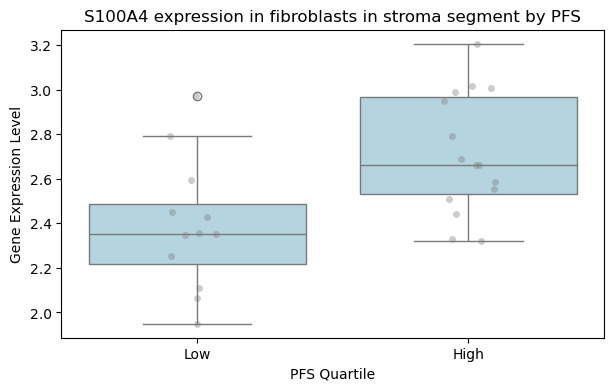

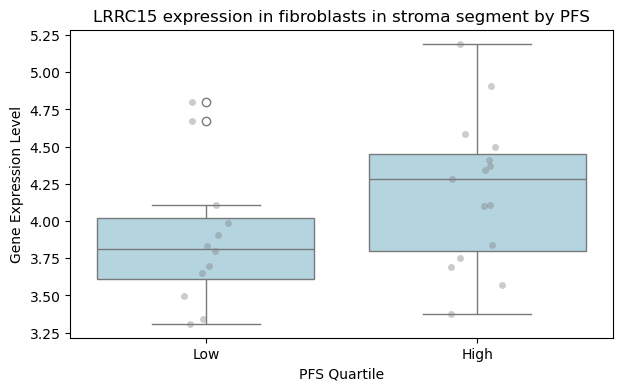

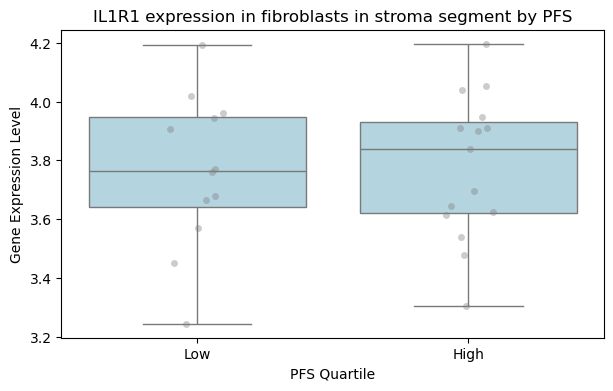

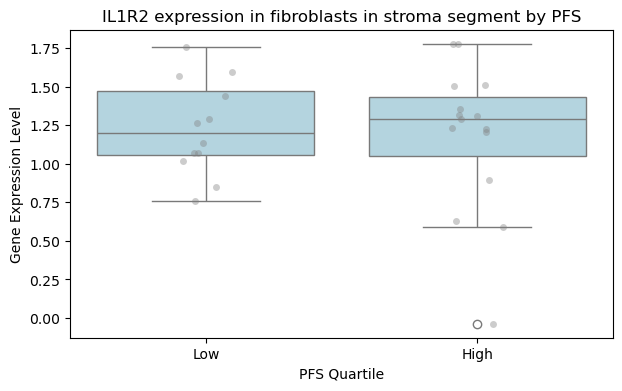

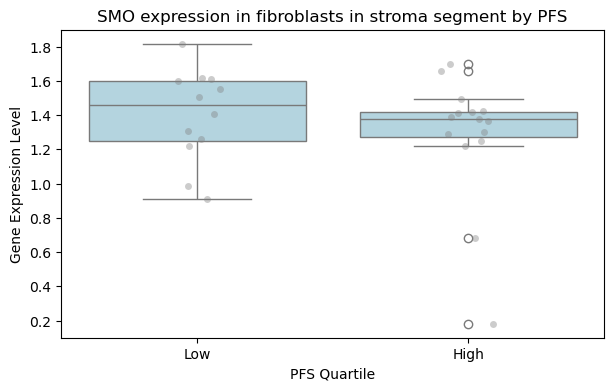

In [17]:
for gene in target_CAFs:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="PFS_HL_group",y=gene,data=average_stroma_gene_expression, color='lightblue', order=["Low", "High"])
    sns.stripplot(x="PFS_HL_group", y=gene, data=average_stroma_gene_expression, color='grey', alpha=0.4, jitter=True, order=["Low", "High"])
    plt.title(f"{gene} expression in fibroblasts in stroma segment by PFS")
    plt.xlabel("PFS Quartile")
    plt.ylabel("Gene Expression Level")
    plt.show()

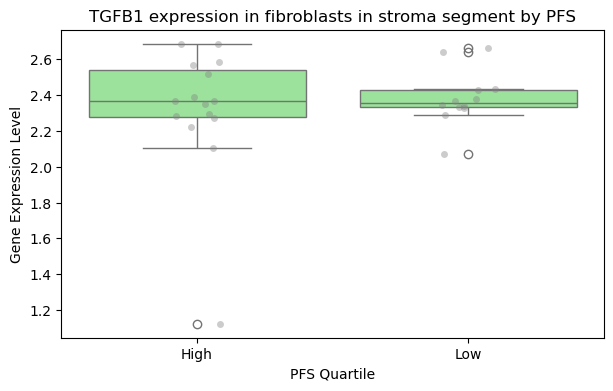

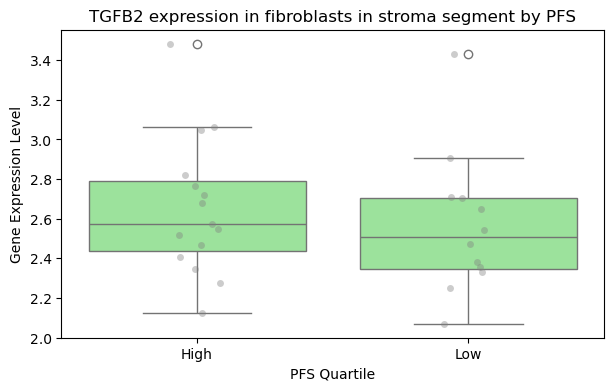

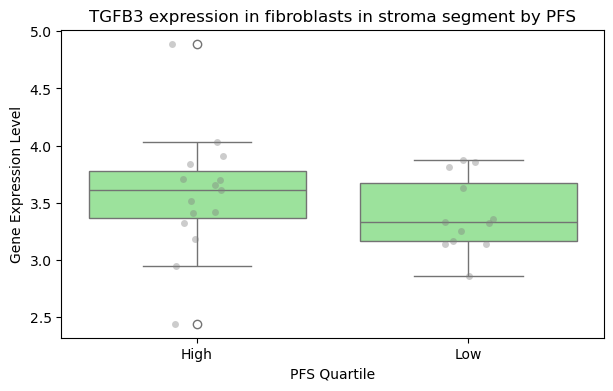

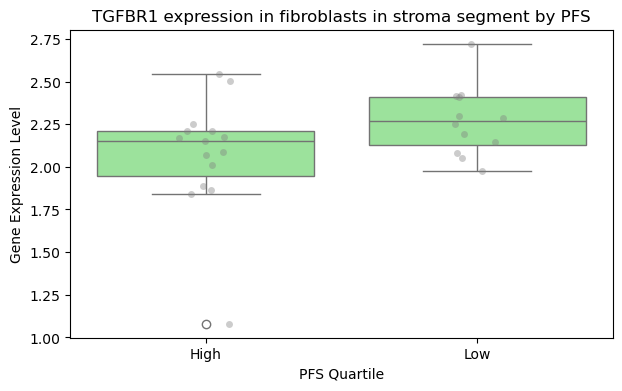

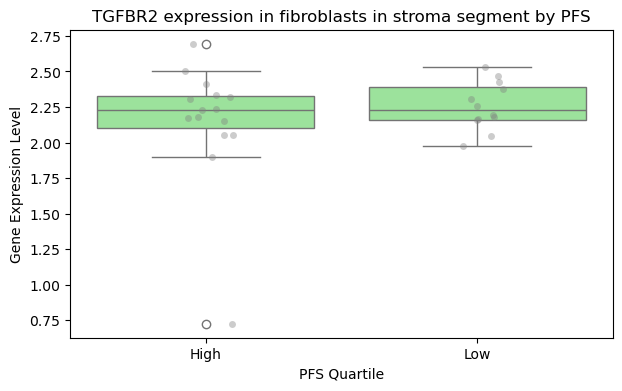

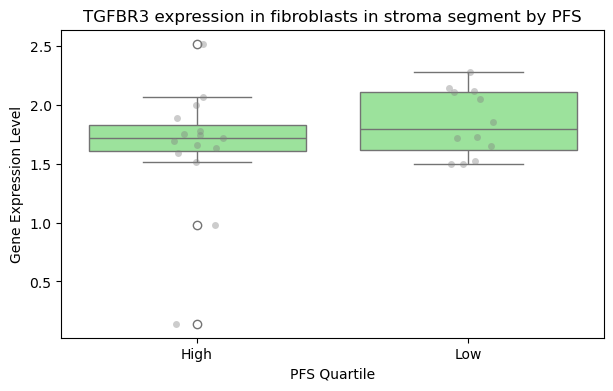

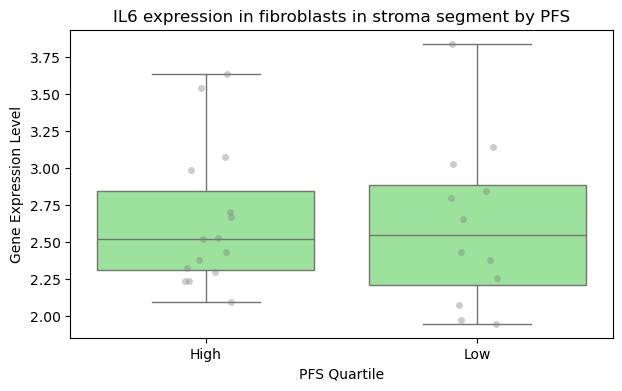

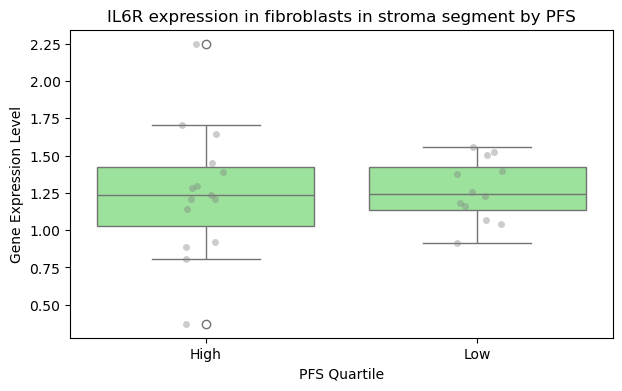

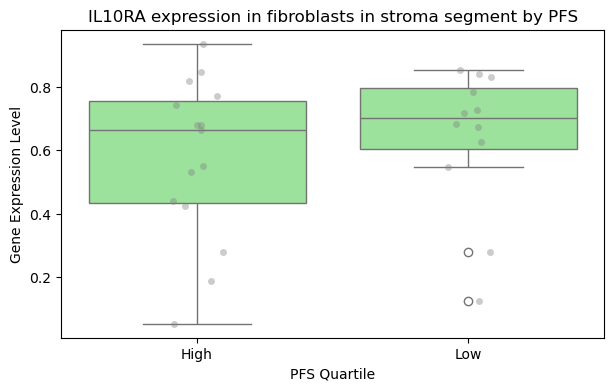

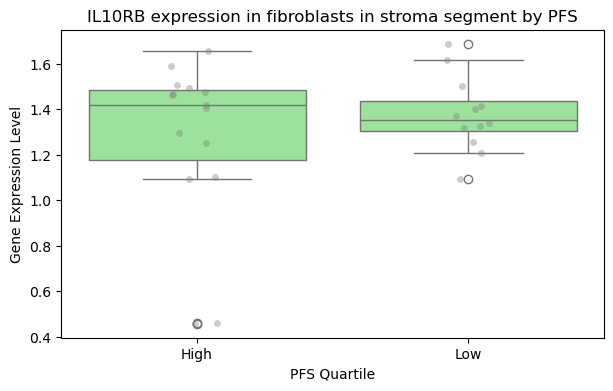

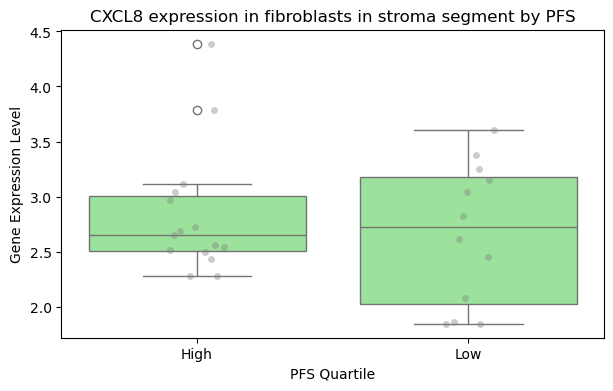

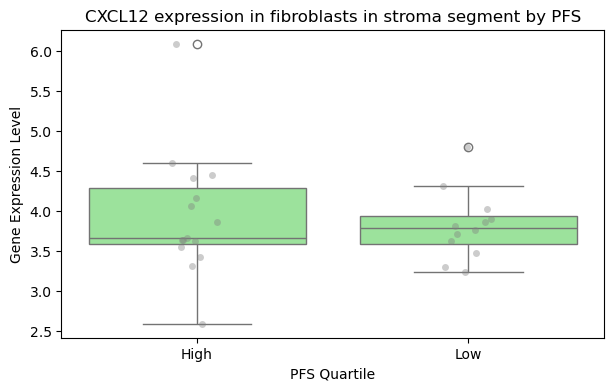

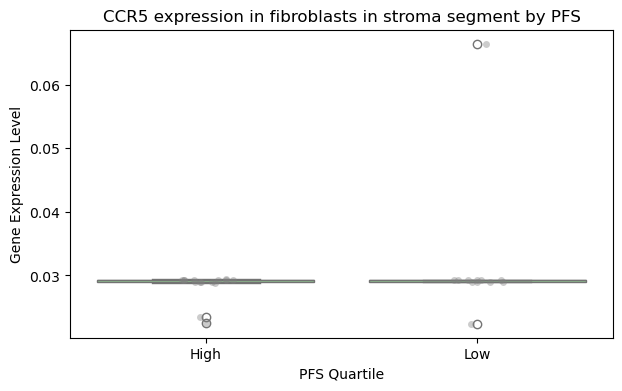

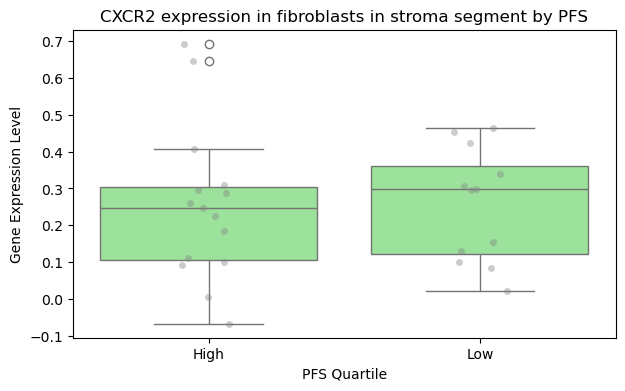

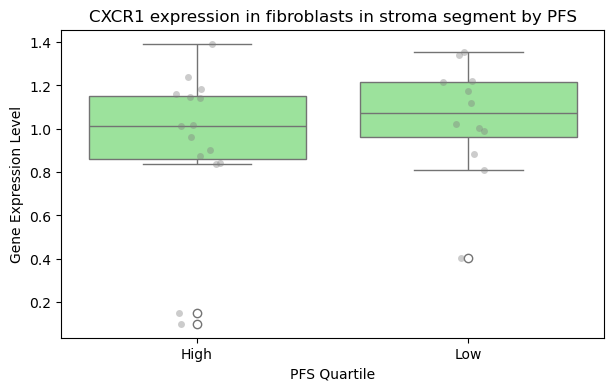

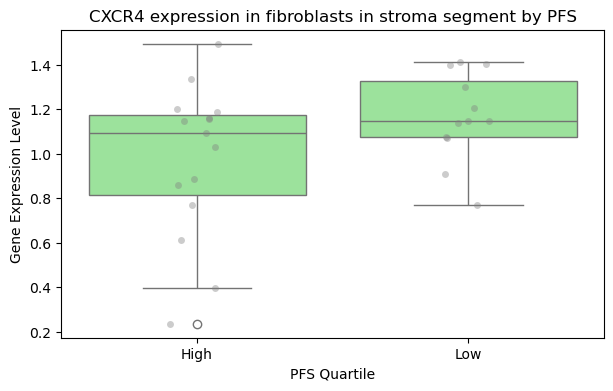

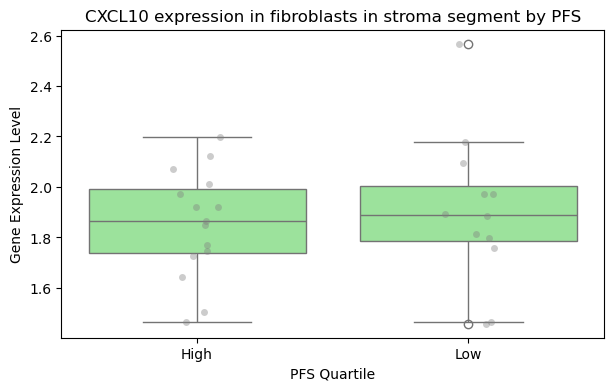

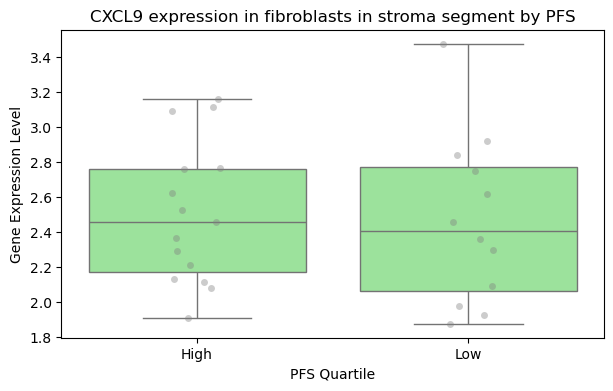

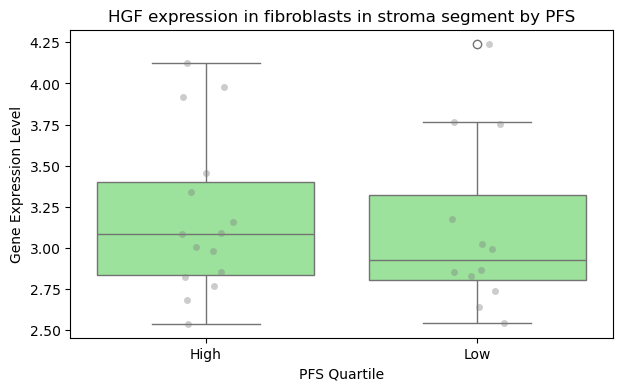

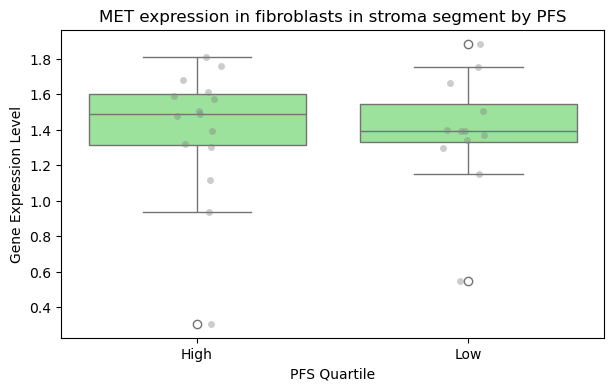

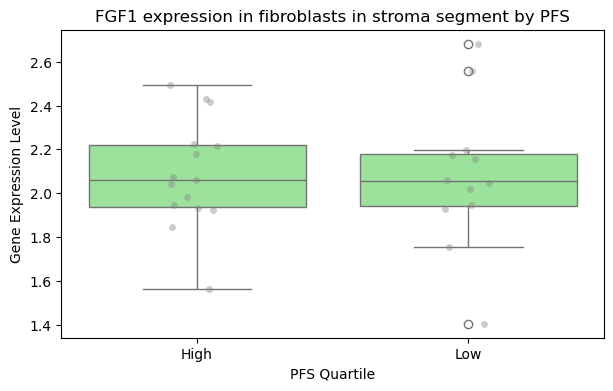

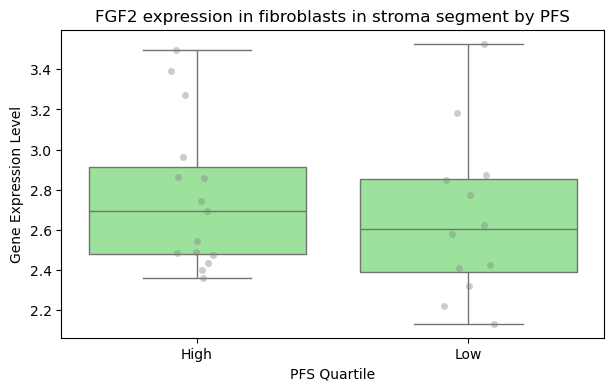

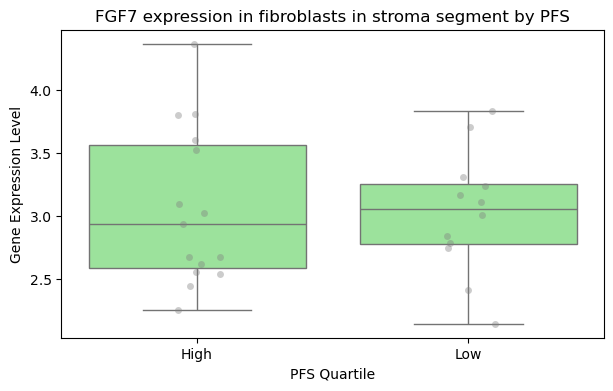

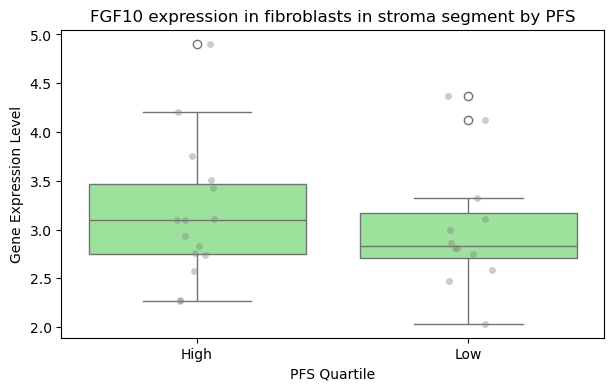

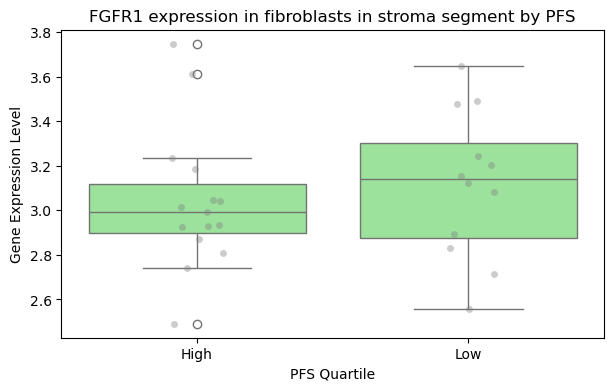

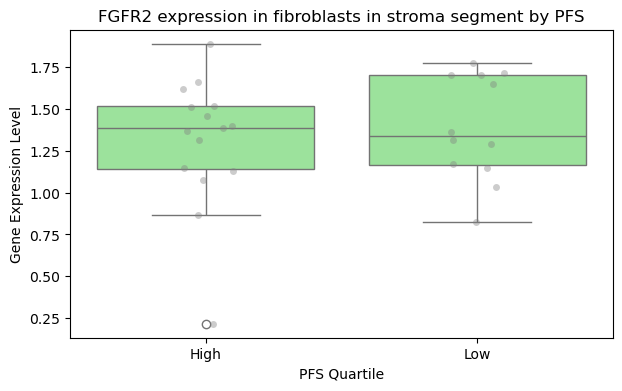

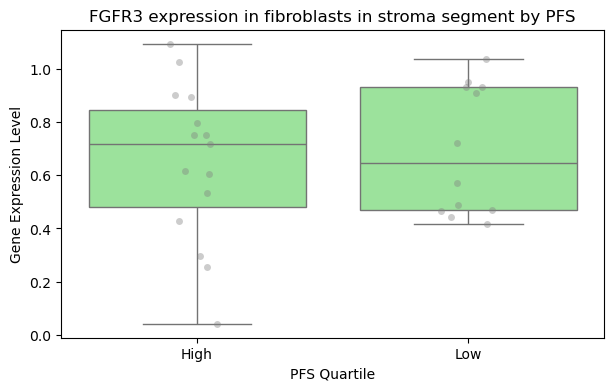

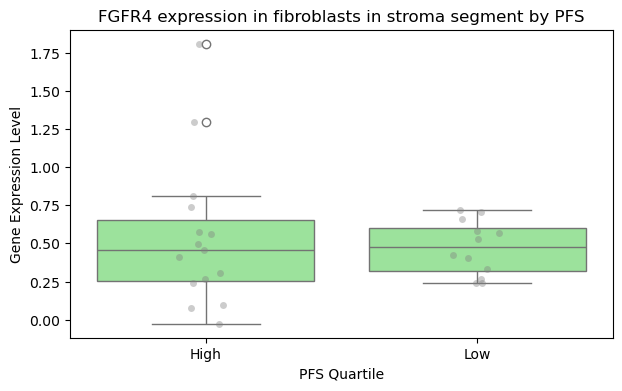

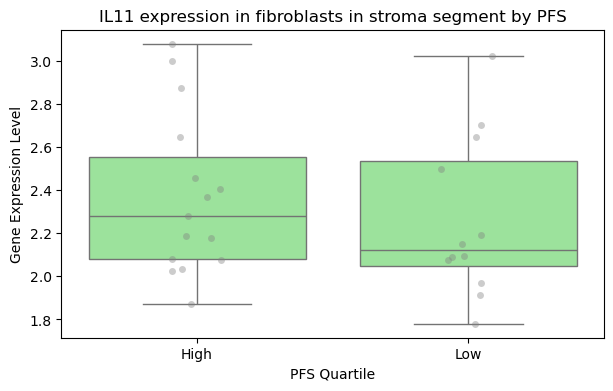

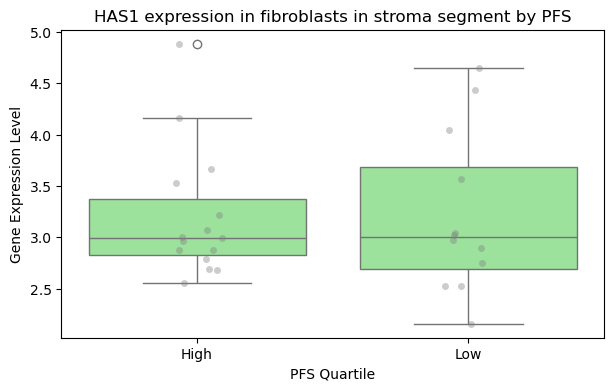

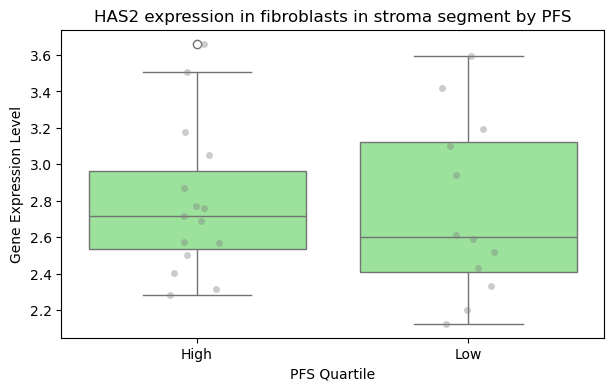

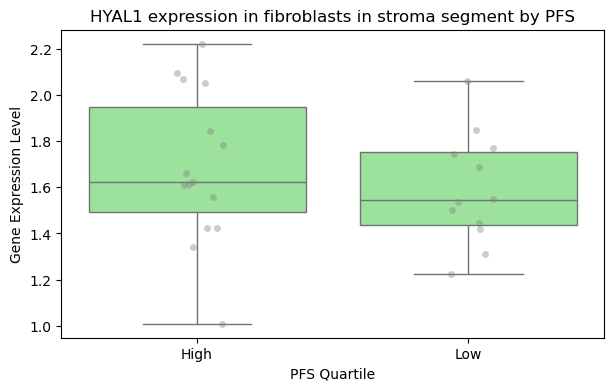

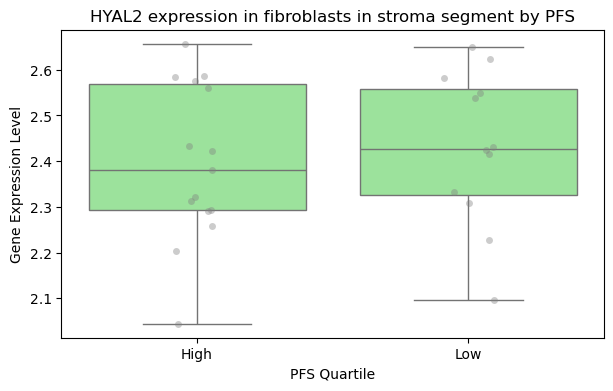

In [16]:
for gene in target_receptors_molecules:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="PFS_HL_group",y=gene,data=average_stroma_gene_expression, color='lightgreen')
    sns.stripplot(x="PFS_HL_group", y=gene, data=average_stroma_gene_expression, color='grey', alpha=0.4, jitter=True)
    plt.title(f"{gene} expression in fibroblasts in stroma segment by PFS")
    plt.xlabel("PFS Quartile")
    plt.ylabel("Gene Expression Level")
    plt.show()